In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score


In [15]:
data = pd.read_csv("fashion-mnist_train.csv")

In [16]:
X = data.drop("label", axis=1).values # The pixels (0-255)
y = data["label"].values              # The target (0-9)

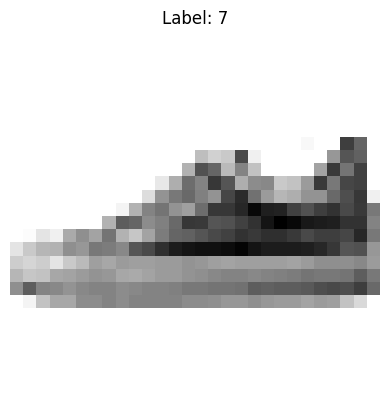

In [17]:
some_item = X[21]
some_item_image = some_item.reshape(28, 28)

plt.imshow(some_item_image, cmap="binary")
plt.axis("off")
plt.title(f"Label: {y[21]}")
plt.show()


In [18]:
y_train_sneaker = (y == 7) 

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X, y_train_sneaker)

print(f"Is this a sneaker? {sgd_clf.predict([some_item])}")


Is this a sneaker? [ True]


In [19]:

# --- PERFORMANCE METRICS ---
# Confusion Matrix
y_train_pred = cross_val_predict(sgd_clf, X, y_train_sneaker, cv=5
                                 )
cm = confusion_matrix(y_train_sneaker, y_train_pred)
print("\nConfusion Matrix:")
print(cm)

# Precision & Recall & F1 Score
print()
print(f"Precision: {precision_score(y_train_sneaker, y_train_pred):.2f}")
print(f"Recall: {recall_score(y_train_sneaker, y_train_pred):.2f}")
print(f"F1 Score:  {f1_score(y_train_sneaker, y_train_pred):.2%}")


Confusion Matrix:
[[53389   611]
 [  770  5230]]

Precision: 0.90
Recall: 0.87
F1 Score:  88.34%


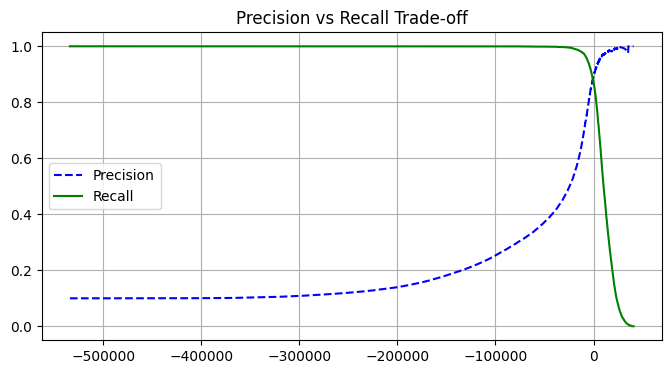

In [20]:
#if you increase the threshold to get higher Precision (fewer false alarms), 
#your Recall will drop (you miss more real sneakers).
y_scores = cross_val_predict(sgd_clf, X, y_train_sneaker, cv=5, method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_sneaker, y_scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1]   , "g-" , label="Recall")
plt.title("Precision vs Recall Trade-off")
plt.legend()
plt.grid(True)
plt.show()

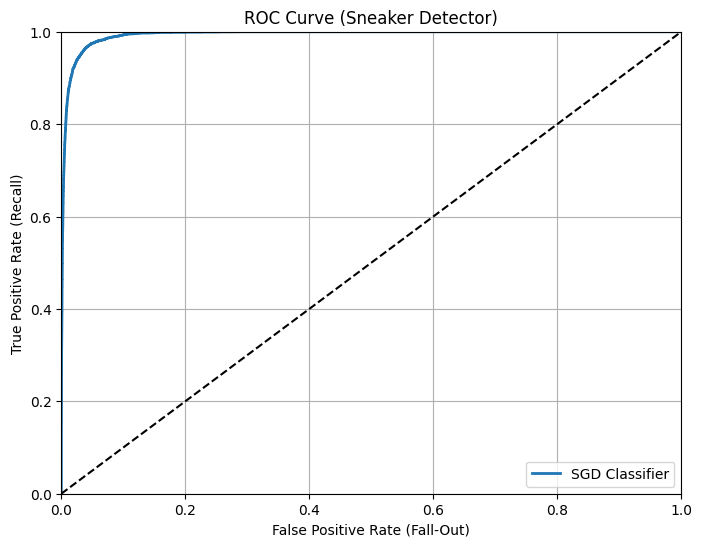

ROC AUC Score: 0.9932


In [27]:
# y_scores = cross_val_predict(sgd_clf, X, y_train_sneaker, cv=5, method="decision_function")

# ROC metrics
fpr, tpr, thresholds = roc_curve(y_train_sneaker, y_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label="SGD Classifier")
plt.plot([0, 1], [0, 1], 'k--') 
plt.axis([0, 1, 0, 1])
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Sneaker Detector)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 4. The Score (Area Under Curve)
# Perfect = 1.0, Random = 0.5
roc_score = roc_auc_score(y_train_sneaker, y_scores)
print(f"ROC AUC Score: {roc_score:.4f}")

In [22]:
print(y_scores[90:100])
print(y_train_sneaker[90:100])

[-228253.01096963   -4378.17742773 -258833.53181491 -164856.3008962
   22854.06115272 -105134.88096401   11598.03846976  -60485.96354985
 -319224.87777752 -161895.95381822]
[False False False False  True False False False False False]


MULTICLASS CLASSIFICATION

In [30]:
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Predict the same item (Now it should say '7' specifically, not just True/False)
print(f"\nMulticlass Prediction: {forest_clf.predict([some_item])}")
print(f"Decision Scores: {forest_clf.predict_proba([some_item])}")


Multiclass Prediction: [7]
Decision Scores: [[0.   0.   0.   0.   0.   0.02 0.   0.97 0.   0.01]]


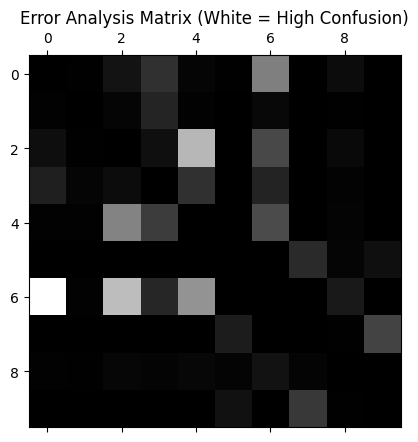

In [ ]:
# --- STEP 5: ERROR ANALYSIS ---

y_train_pred_forest = cross_val_predict(forest_clf, X, y, cv=5)
conf_mx = confusion_matrix(y, y_train_pred_forest)

# Normalize errors to see rates instead of absolute numbers
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

np.fill_diagonal(norm_conf_mx, 0)  # Fill diagonal with zeros to keep only the errors

plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.title("Error Analysis Matrix (White = High Confusion)")
plt.show()

In [31]:
conf_mx

array([[5198,    4,   72,  182,   21,    5,  473,    0,   45,    0],
       [  10, 5787,   21,  138,    8,    0,   32,    0,    4,    0],
       [  55,    4, 4899,   57,  679,    2,  269,    0,   35,    0],
       [ 117,   19,   45, 5495,  182,    0,  130,    0,   12,    0],
       [  10,    8,  487,  226, 4972,    1,  279,    0,   17,    0],
       [   0,    1,    0,    3,    0, 5761,    0,  158,   19,   58],
       [ 949,   10,  704,  141,  547,    3, 3552,    0,   94,    0],
       [   0,    0,    0,    0,    0,  106,    0, 5638,    7,  249],
       [   8,    5,   23,   18,   26,   18,   67,   15, 5817,    3],
       [   0,    0,    1,    1,    0,   66,    3,  212,    5, 5712]],
      dtype=int64)

In [25]:
from sklearn.metrics import classification_report

print("--- Multiclass Classification Report ---")
print(classification_report(y,
                            y_train_pred_forest, 
                            target_names=["T-shirt", "Trouser", "Pullover", "Dress", "Coat", 
                                          "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]))

--- Multiclass Classification Report ---
              precision    recall  f1-score   support

     T-shirt       0.82      0.87      0.84      6000
     Trouser       0.99      0.96      0.98      6000
    Pullover       0.78      0.82      0.80      6000
       Dress       0.88      0.92      0.90      6000
        Coat       0.77      0.83      0.80      6000
      Sandal       0.97      0.96      0.96      6000
       Shirt       0.74      0.59      0.66      6000
     Sneaker       0.94      0.94      0.94      6000
         Bag       0.96      0.97      0.97      6000
        Boot       0.95      0.95      0.95      6000

    accuracy                           0.88     60000
   macro avg       0.88      0.88      0.88     60000
weighted avg       0.88      0.88      0.88     60000



In [26]:
# --- FINAL EVALUATION ON TEST SET ---

test_data = pd.read_csv("fashion-mnist_test.csv")
X_test = test_data.drop("label", axis=1).values
y_test = test_data["label"].values


final_predictions = forest_clf.predict(X_test)


from sklearn.metrics import accuracy_score
final_acc = accuracy_score(y_test, final_predictions)

print("-" * 30)
print(f"FINAL TEST ACCURACY: {final_acc:.2%}")
print("-" * 30)

------------------------------
FINAL TEST ACCURACY: 88.47%
------------------------------
